# PETR4: previsão e risco com séries temporais

Notebook de execução do projeto *Intelligent Stock Predictor*, adaptado para a disciplina de Aplicações em Finanças, Controladoria e Compliance. Os dados vêm do Yahoo Finance (preços ajustados por dividendos e JCP), e cada etapa chama uma função do `pipeline.py`, de modo que o mesmo estudo roda aqui, pela linha de comando (`python main.py`) ou pela interface (`python app.py`).

**Autor:** Izael Castro

## 0. Preparação

No Colab, envie o zip do projeto pela barra lateral e descomente as linhas abaixo. Localmente, basta abrir o notebook a partir da pasta `notebooks/`.

In [1]:
# !unzip -q intelligent_stock_predictor.zip -d /content
# %cd /content/intelligent_stock_predictor
# !pip install -q -r requirements.txt

import os
import sys

raiz = os.getcwd() if os.path.exists("config.py") else os.path.abspath("..")
os.chdir(raiz)
sys.path.insert(0, raiz)

import pandas as pd
import config
import pipeline
from core import dados

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1. Dados

Download via `yfinance` com cache em `data/`. Linhas parciais do Yahoo (abertura, máxima e mínima zeradas, volume nulo) são descartadas, e a série não é reindexada para dias úteis, porque preencher feriados com o preço anterior cria retornos zero artificiais.

In [2]:
base, rotulos = pipeline.etapa_dados(atualizar=True)
dados.resumo_periodos(base.index)

[dados] PETR4.SA: 2916 pregões lidos do cache (02/01/2015 a 02/10/2026)


,inicio,fim,pregoes
periodo,,,
treino,2015-01-05,2022-12-29,1977
validacao,2023-01-02,2023-12-28,248
teste,2024-01-02,2026-10-02,690


## 2. Diagnóstico

Testes de raiz unitária no log-preço (com e sem tendência) e no log-retorno, momentos do retorno e dependência temporal. O Ljung-Box no retorno bruto tende a rejeitar mais que o nominal quando a volatilidade se agrupa; por isso ele aparece também sobre o retorno padronizado pela volatilidade EWMA.

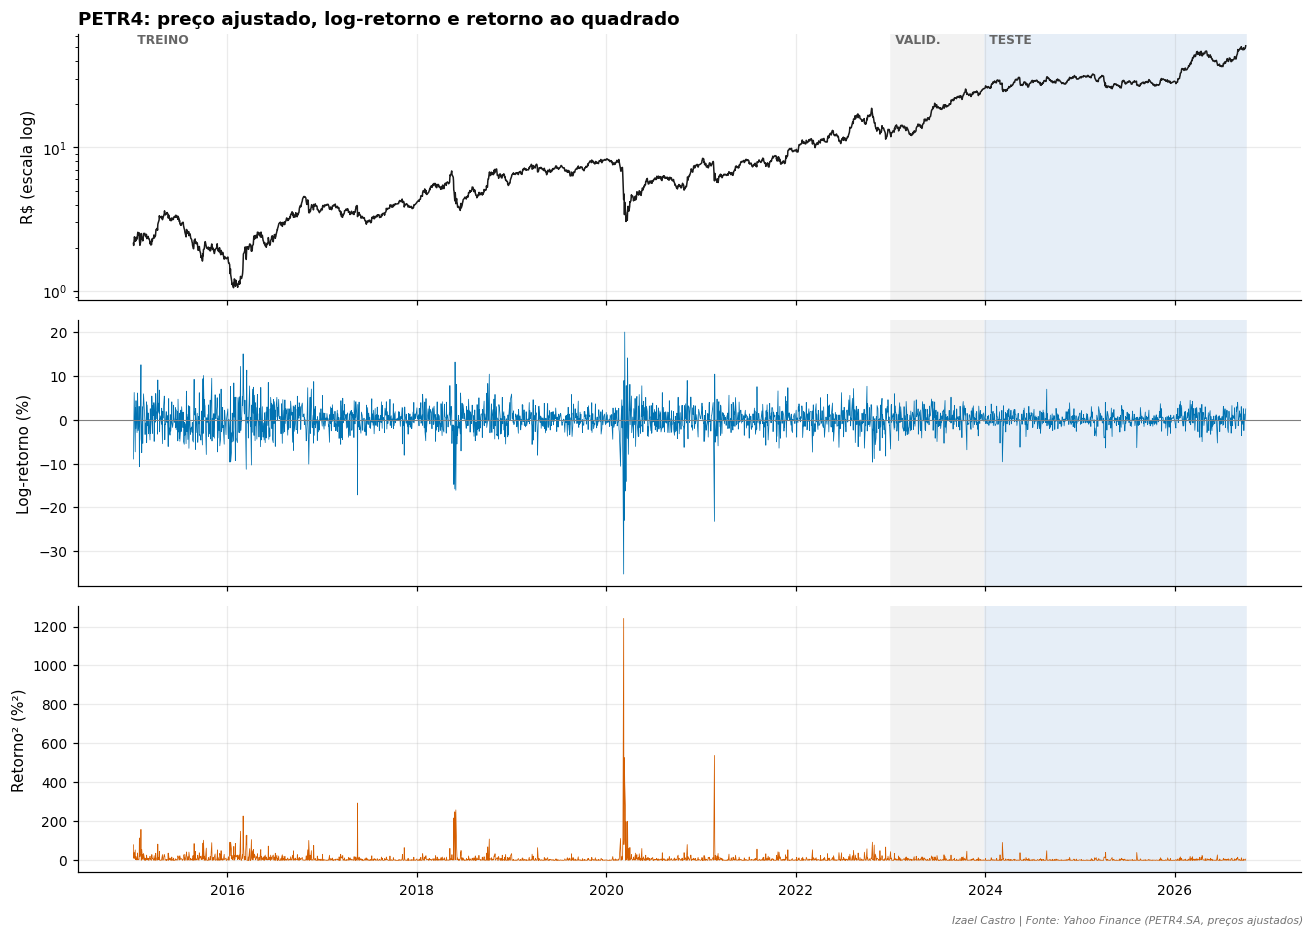

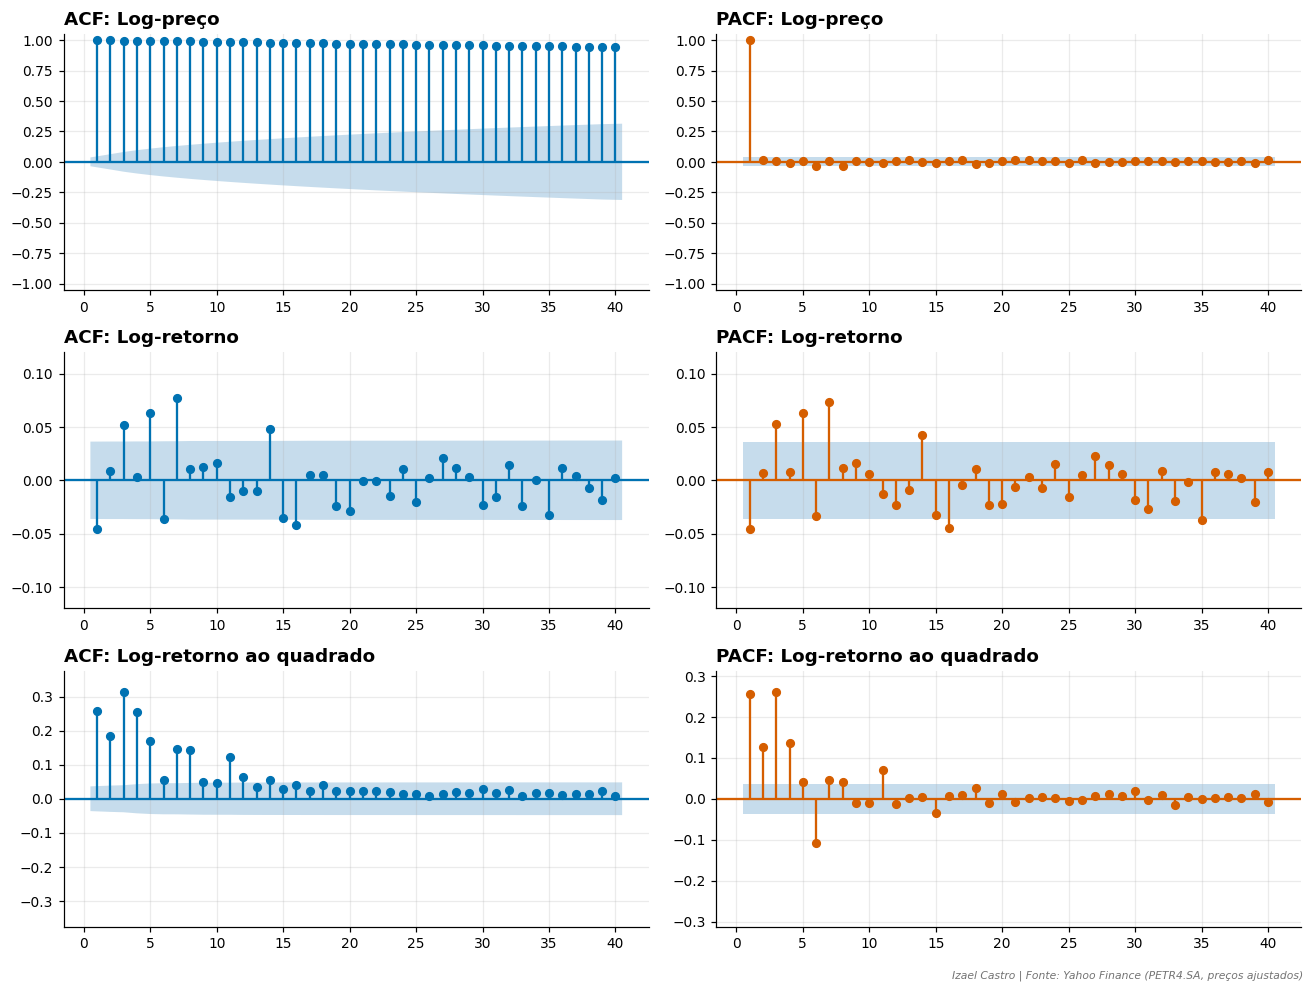

,especificacao,ADF_estat,ADF_p,KPSS_estat,KPSS_p,leitura
serie,,,,,,
log-preço,c,-0.5542,0.8810,8.7064,0.0100,raiz unitaria
log-preço,ct,-3.8086,0.0161,0.4503,0.0100,inconclusivo
log-retorno,c,-18.1267,0.0000,0.0383,0.1000,estacionaria


,valor
pregoes,"2,915.0000"
media_diaria,0.0011
dp_diario,0.0285
assimetria,-1.1131
curtose_excesso,14.9242
jarque_bera_p,0.0000
deriva_log_anual,0.2665
erro_padrao_deriva_anual,0.1332
vol_anual,0.4529
mu_aritmetico_anual,0.3691


,LB_retorno_p,LB_retorno_padronizado_p,LB_retorno2_p,ARCH_LM_10_p
defasagens,,,,
5,0.0001,0.1446,0.0000,0.0000
10,0.0000,0.0310,0.0000,0.0000
20,0.0000,0.1328,0.0000,0.0000


In [3]:
diag = pipeline.etapa_diagnostico(base, rotulos, mostrar=True)
display(diag["raiz_unitaria"])
display(diag["momentos"].to_frame("valor"))
display(diag["dependencia"])

## 3. Previsão um passo à frente no teste

Quatro previsões do log-retorno do pregão seguinte, todas com informação até o dia anterior: passeio aleatório (retorno zero), passeio com deriva (média do treino), ARIMA com ordem e coeficientes estimados só no treino e uma rede GRU treinada no treino com parada antecipada na validação. As métricas comparam cada modelo ao passeio aleatório: U de Theil abaixo de 1, R² fora da amostra positivo e Diebold-Mariano com estatística negativa e p-valor baixo indicariam ganho real. O R² do preço aparece para mostrar que ele fica perto de 1 em qualquer modelo, inclusive no passeio aleatório.

[avaliacao] ARIMA escolhido no treino: (1, 1, 0) sem constante (AICc -7939.7)


[avaliacao] GRU treinada em 20 épocas (melhor na validação: 5)


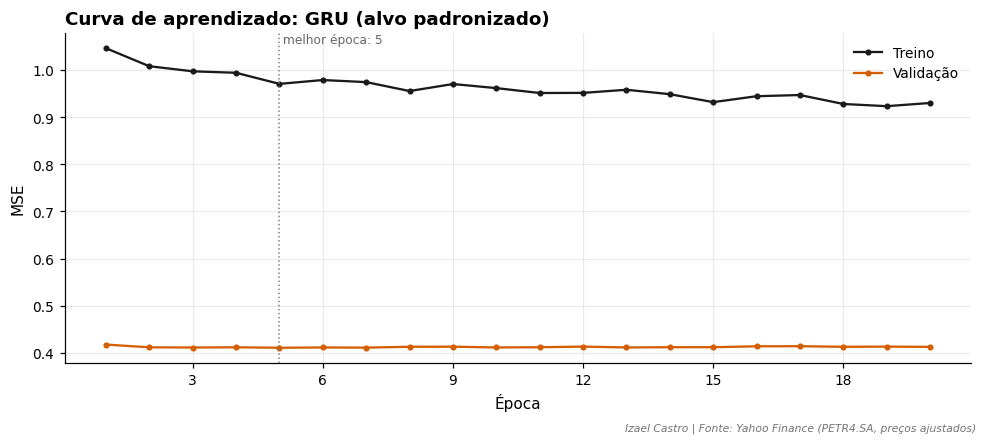

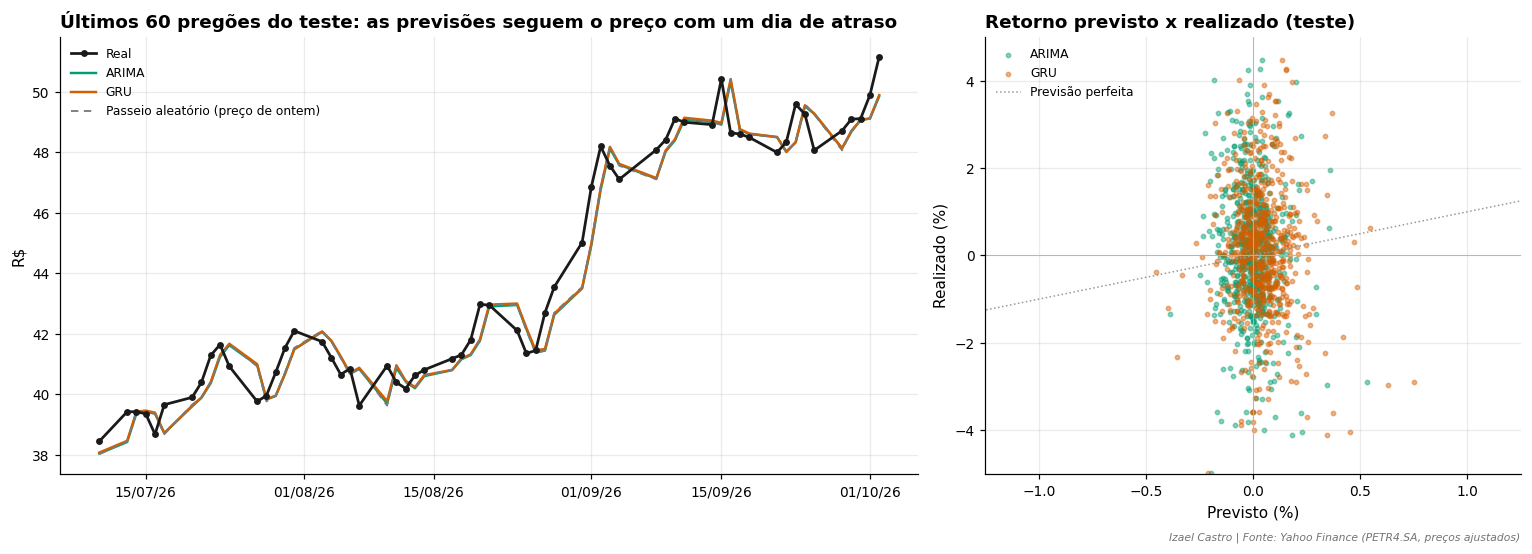

Pregões no teste: 690 | dias de alta: 53.5%


,RMSE_preco,MAE_preco,MAPE_preco_%,R2_preco,RMSE_ret_%,MASE_ret,U_Theil,R2_fora_amostra_%,acerto_direcional_%,binomial_p,DM_estat,DM_p
modelo,,,,,,,,,,,,
passeio_aleatorio,0.5417,0.3845,1.1730,0.9925,1.6060,0.5272,1.0000,0.0000,NaN,NaN,NaN,NaN
passeio_com_deriva,0.5404,0.3830,1.1694,0.9925,1.6029,0.5251,0.9981,0.3812,53.4783,0.0735,-0.9277,0.3539
arima,0.5452,0.3865,1.1782,0.9924,1.6158,0.5296,1.0061,-1.2209,46.6374,0.0852,2.3498,0.0191
gru,0.5444,0.3861,1.1781,0.9924,1.6155,0.5292,1.0059,-1.1830,48.8406,0.5680,1.5534,0.1208


In [4]:
aval = pipeline.etapa_avaliacao(base, rotulos, tipo_rede="gru", mostrar=True)
tabela = aval["tabela"]
print(f"Pregões no teste: {tabela.attrs['pregoes']} | dias de alta: {tabela.attrs['taxa_dias_alta_%']:.1f}%")
tabela

## 4. Risco: VaR EWMA de 1 dia

Volatilidade EWMA com lambda de 0,94 (RiskMetrics), VaR normal de 95% e 99% para uma carteira de R$ 1 milhão, comparado à perda do mesmo dia. O teste de Kupiec verifica a proporção de violações, e o de Christoffersen verifica se elas chegam agrupadas.

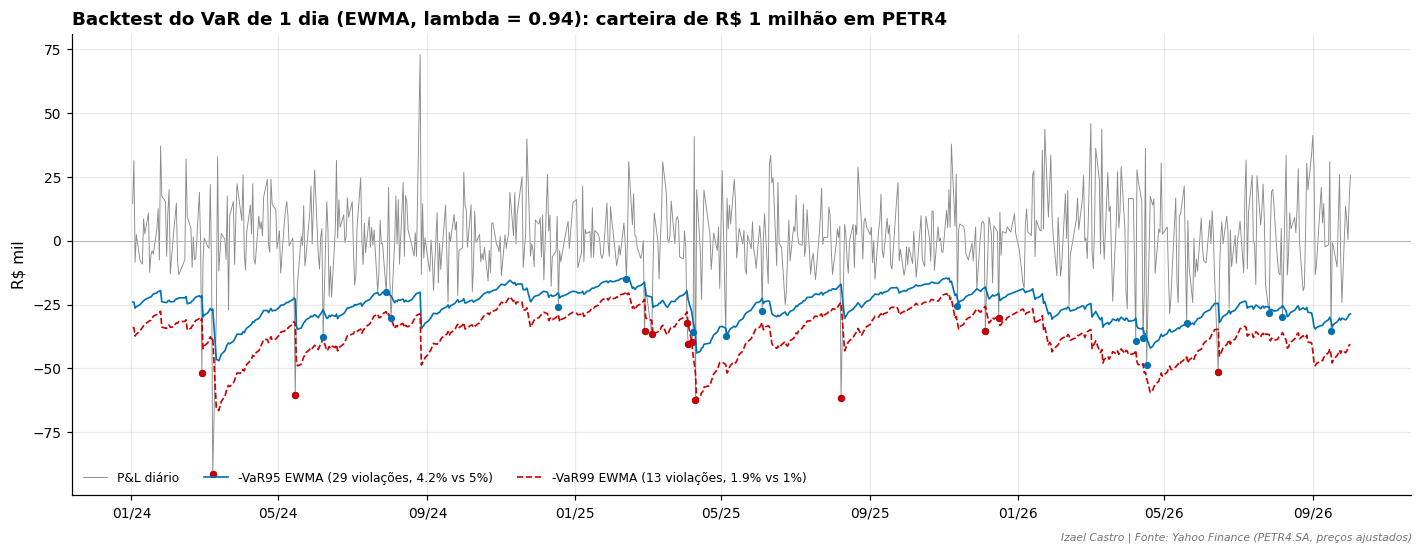

,dias,violacoes,taxa_obs_%,taxa_esperada_%,Kupiec_p,Christoffersen_ind_p,cobertura_condicional_p
nivel,,,,,,,
VaR95,690,29,4.2029,5.0000,0.3238,0.1498,0.2178
VaR99,690,13,1.8841,1.0000,0.0376,0.0202,0.0078


In [5]:
risc = pipeline.etapa_risco(base, rotulos, mostrar=True)
risc["resumo"]

## 5. Projeção por GBM

Projeção de um ano a partir do último fechamento. A média do log-retorno já estima a deriva do log-preço (mu - sigma²/2), então ela entra direto, sem nova correção de Itô. Os intervalos vêm dos quantis do log-preço levados à escala de preço, o que preserva a assimetria da lognormal. A tabela compara três cenários de parâmetros, porque a deriva histórica tem erro padrão alto e a volatilidade muda bastante entre o histórico e o EWMA corrente.

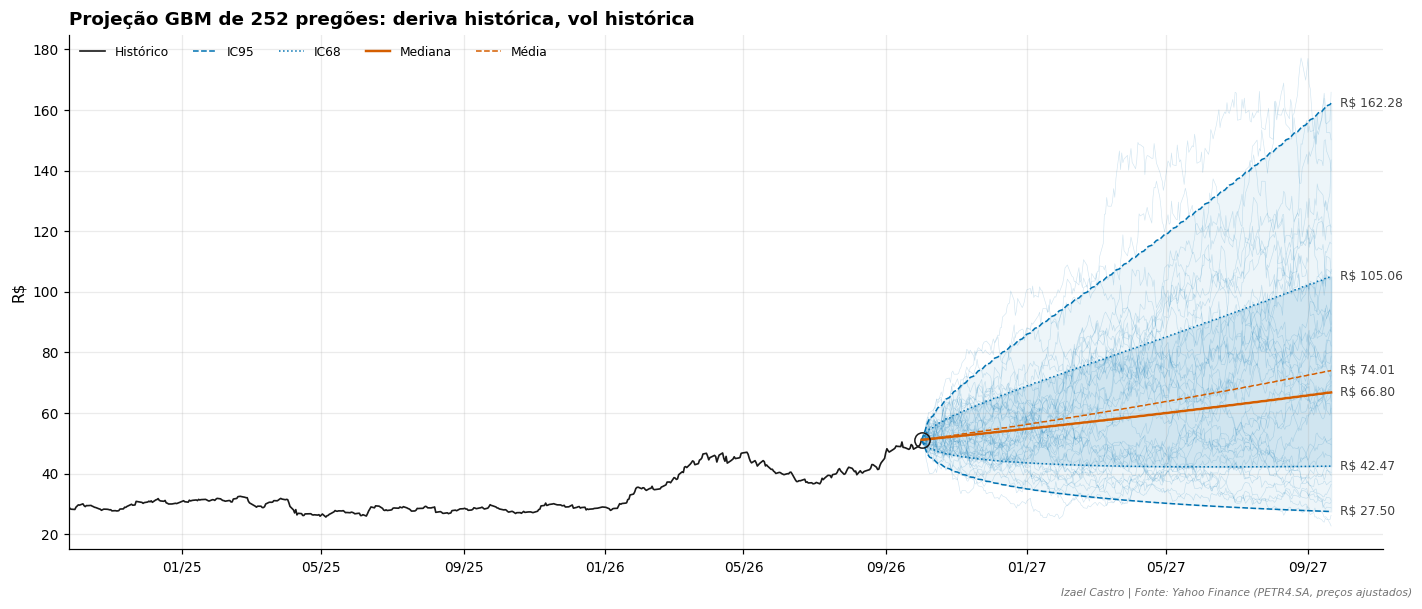

cenario,"deriva histórica, vol histórica","deriva histórica, vol EWMA atual","deriva zero, vol histórica"
deriva_log_anual_%,26.6520,26.6520,0.0000
vol_anual_%,45.2884,28.5829,45.2884
S0,51.1700,51.1700,51.1700
mediana_analitica,66.7980,66.7980,51.1700
media_analitica,74.0119,69.5832,56.6961
mediana_simulada,66.9230,66.8769,51.2657
media_simulada,74.3493,69.7751,56.9546
P(S_T < S0)_analitica,0.2781,0.1756,0.5000
P(S_T < S0)_simulada,0.2739,0.1722,0.4987
IC68_inf,42.4696,50.1914,32.5335


In [6]:
proj = pipeline.etapa_projecao(base, risc["vol_ewma_proximo_pregao"], mostrar=True)
proj["cenarios"].T

## 6. Resumo

Gera `results/PETR4/resumo.md` com todas as tabelas desta execução.

In [7]:
texto = pipeline.gerar_resumo(base, rotulos, diag, aval, risc, proj)
print(f"Resumo salvo em results/{config.NOME_ATIVO}/resumo.md")

Resumo salvo em results/PETR4/resumo.md
